In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("data/train.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 891
Columns: 12


In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print("Dataset shape:", df.shape)

Dataset shape: (891, 12)


In [5]:
print("Column names:")
print(df.columns.tolist())

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [6]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [7]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [8]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [9]:
print("Numerical summary:")
print(df.describe())

Numerical summary:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [10]:
quality_report = pd.DataFrame({
    'Column': df.columns,
    'Null_Count': df.isnull().sum().values,
    'Null_Percentage': (df.isnull().mean().values * 100).round(2),
    'Data_Type': df.dtypes.astype(str).values,
    'Unique_Values': df.nunique().values
})

quality_report

,Column,Null_Count,Null_Percentage,Data_Type,Unique_Values
0,PassengerId,0,0.00,int64,891
1,Survived,0,0.00,int64,2
2,Pclass,0,0.00,int64,3
3,Name,0,0.00,str,891
4,Sex,0,0.00,str,2
5,Age,177,19.87,float64,88
6,SibSp,0,0.00,int64,7
7,Parch,0,0.00,int64,7
8,Ticket,0,0.00,str,681
9,Fare,0,0.00,float64,248


# Data Quality Report

The Titanic dataset was inspected before cleaning to identify major data
quality issues.

The inspection included:

- Missing values in each column
- Duplicate rows
- Data types
- Number of unique values
- Numerical value ranges and possible anomalies

The quality report provides a baseline for deciding which cleaning
operations are required.

In [11]:
age_median = df['Age'].median()

df['Age'] = df['Age'].fillna(age_median)

print("Median Age used:", age_median)
print("Missing Age values after cleaning:", df['Age'].isnull().sum())

Median Age used: 28.0
Missing Age values after cleaning: 0


In [12]:
embarked_mode = df['Embarked'].mode()[0]

df['Embarked'] = df['Embarked'].fillna(embarked_mode)

print("Mode used for Embarked:", embarked_mode)
print("Missing Embarked values after cleaning:", df['Embarked'].isnull().sum())


Mode used for Embarked: S
Missing Embarked values after cleaning: 0


In [13]:
df['Cabin'] = df['Cabin'].fillna('Unknown')

print("Missing Cabin values after cleaning:", df['Cabin'].isnull().sum())

Missing Cabin values after cleaning: 0


In [14]:
print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


# Missing Data Handling Decisions

### Age
Missing Age values were replaced using median imputation. Age is a
numerical variable, and the median is less affected by extreme values
than the mean.

### Embarked
Missing Embarked values were replaced using mode imputation because
Embarked is a categorical variable.

### Cabin
Missing Cabin values were replaced with "Unknown". This avoids deleting
large numbers of passenger records while clearly indicating that cabin
information was not available.

These strategies were selected based on the type of each variable and
the amount and nature of missing information.

In [15]:
duplicates_before = df.duplicated().sum()

print("Duplicate rows before cleaning:", duplicates_before)

Duplicate rows before cleaning: 0


In [16]:
df = df.drop_duplicates()

duplicates_after = df.duplicated().sum()

print("Duplicate rows after cleaning:", duplicates_after)

Duplicate rows after cleaning: 0


# Duplicate Removal

Duplicate rows were checked using pandas duplicated().

Exact duplicate records were removed using drop_duplicates().

The dataset contained no duplicate rows, so no records were removed
during this step.

In [17]:
print("Current dataset shape:", df.shape)

Current dataset shape: (891, 12)


In [18]:
df['Sex'] = df['Sex'].str.strip().str.lower().str.title()

print("Sex values after standardization:")
print(df['Sex'].value_counts())

Sex values after standardization:
Sex
Male      577
Female    314
Name: count, dtype: int64


In [19]:
df['Embarked'] = df['Embarked'].str.strip().str.upper()

print("Embarked values after standardization:")
print(df['Embarked'].value_counts())

Embarked values after standardization:
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


In [20]:
print("Unique Sex values:", df['Sex'].unique())
print("Unique Embarked values:", df['Embarked'].unique())

Unique Sex values: <StringArray>
['Male', 'Female']
Length: 2, dtype: str
Unique Embarked values: <StringArray>
['S', 'C', 'Q']
Length: 3, dtype: str


# Data Standardization

Categorical values were standardized to maintain consistent formatting.

- `Sex` values were stripped of extra spaces and converted to title case.
- `Embarked` values were stripped of extra spaces and converted to uppercase.
- This prevents formatting differences from being treated as different categories.

The source Titanic dataset already contains largely consistent categorical
values, so this step acts as a validation and normalization process.

In [21]:
print("Current data types:")
print(df.dtypes)

Current data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


In [22]:
df['PassengerId'] = pd.to_numeric(df['PassengerId'], errors='coerce')
df['Survived'] = pd.to_numeric(df['Survived'], errors='coerce')
df['Pclass'] = pd.to_numeric(df['Pclass'], errors='coerce')
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['SibSp'] = pd.to_numeric(df['SibSp'], errors='coerce')
df['Parch'] = pd.to_numeric(df['Parch'], errors='coerce')
df['Fare'] = pd.to_numeric(df['Fare'], errors='coerce')

print("Numerical columns converted successfully!")

Numerical columns converted successfully!


In [23]:
df['Sex'] = df['Sex'].astype('string')
df['Embarked'] = df['Embarked'].astype('string')
df['Cabin'] = df['Cabin'].astype('string')

print("Categorical columns converted successfully!")

Categorical columns converted successfully!


In [24]:
print("Data types after correction:")
print(df.dtypes)

Data types after correction:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex             string
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin           string
Embarked        string
dtype: object


# Data Type Correction

The data types of important columns were checked and corrected.

- PassengerId, Survived, Pclass, Age, SibSp, Parch and Fare were converted to numerical types.
- Sex, Embarked and Cabin were converted to string types.
- `pd.to_numeric()` was used to ensure numerical columns contain valid numeric values.

Correct data types make the dataset easier to analyze and reduce errors during
statistical analysis and visualization.

In [25]:
print("Survived values:")
print(df['Survived'].unique())

Survived values:
[0 1]


In [26]:
print("Passenger class values:")
print(df['Pclass'].unique())

Passenger class values:
[3 1 2]


In [27]:
print("Age range:")
print("Minimum Age:", df['Age'].min())
print("Maximum Age:", df['Age'].max())

print("\nFare range:")
print("Minimum Fare:", df['Fare'].min())
print("Maximum Fare:", df['Fare'].max())

Age range:
Minimum Age: 0.42
Maximum Age: 80.0

Fare range:
Minimum Fare: 0.0
Maximum Fare: 512.3292


In [28]:
print("Negative Age values:", (df['Age'] < 0).sum())
print("Negative Fare values:", (df['Fare'] < 0).sum())

print("Invalid Survived values:",
      (~df['Survived'].isin([0, 1])).sum())

print("Invalid Pclass values:",
      (~df['Pclass'].isin([1, 2, 3])).sum())

Negative Age values: 0
Negative Fare values: 0
Invalid Survived values: 0
Invalid Pclass values: 0


# Value Range and Anomaly Checks

Numerical columns were checked for invalid values and logical anomalies.

- Survived should contain only 0 and 1.
- Pclass should contain only 1, 2 and 3.
- Age should not contain negative values.
- Fare should not contain negative values.

The checks help identify possible data-entry errors before performing
further analysis.

In [29]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]
    
    return outliers, lower_bound, upper_bound

print("IQR function created successfully!")

IQR function created successfully!


In [30]:
age_outliers, age_lower, age_upper = detect_outliers_iqr(df, 'Age')

print("Age lower bound:", age_lower)
print("Age upper bound:", age_upper)
print("Number of Age outliers:", len(age_outliers))

Age lower bound: 2.5
Age upper bound: 54.5
Number of Age outliers: 66


In [31]:
fare_outliers, fare_lower, fare_upper = detect_outliers_iqr(df, 'Fare')

print("Fare lower bound:", fare_lower)
print("Fare upper bound:", fare_upper)
print("Number of Fare outliers:", len(fare_outliers))

Fare lower bound: -26.724
Fare upper bound: 65.6344
Number of Fare outliers: 116


C:\Users\DELL\AppData\Local\Temp\ipykernel_13332\3511764940.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df['Fare'].dropna(), vert=False)


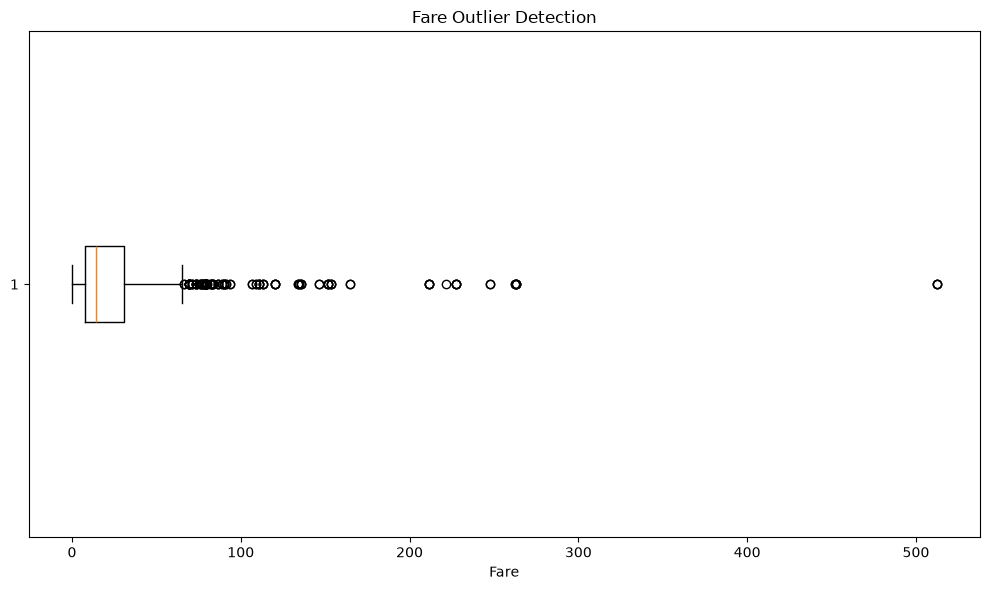

In [32]:
plt.figure(figsize=(10, 6))

plt.boxplot(df['Fare'].dropna(), vert=False)

plt.title('Fare Outlier Detection')
plt.xlabel('Fare')

plt.tight_layout()
plt.show()

# Outlier Detection and Treatment

The IQR method was used to identify potential outliers in the Age and Fare
columns.

Potential outliers were reviewed rather than automatically deleted.

Some unusually high Fare values may represent legitimate first-class or
group ticket purchases. Therefore, these values were retained because they
are not necessarily data-entry errors.

Only logically impossible or clearly incorrect values would be removed or
corrected.

In [33]:
original_df = pd.read_csv("data/train.csv")

print("Original dataset loaded.")
print("Original rows:", len(original_df))
print("Original columns:", len(original_df.columns))

Original dataset loaded.
Original rows: 891
Original columns: 12


In [34]:
before_nulls = original_df.isnull().sum().sum()
before_duplicates = original_df.duplicated().sum()
before_rows = len(original_df)

after_nulls = df.isnull().sum().sum()
after_duplicates = df.duplicated().sum()
after_rows = len(df)

before_after = pd.DataFrame({
    'Metric': [
        'Total Null Values',
        'Duplicate Rows',
        'Total Rows'
    ],
    'Before Cleaning': [
        before_nulls,
        before_duplicates,
        before_rows
    ],
    'After Cleaning': [
        after_nulls,
        after_duplicates,
        after_rows
    ]
})

before_after

,Metric,Before Cleaning,After Cleaning
0,Total Null Values,866,0
1,Duplicate Rows,0,0
2,Total Rows,891,891


In [35]:
dtype_comparison = pd.DataFrame({
    'Column': original_df.columns,
    'Original Data Type': original_df.dtypes.astype(str).values,
    'Final Data Type': df.dtypes.astype(str).values
})

dtype_comparison

,Column,Original Data Type,Final Data Type
0,PassengerId,int64,int64
1,Survived,int64,int64
2,Pclass,int64,int64
3,Name,str,str
4,Sex,str,string
5,Age,float64,float64
6,SibSp,int64,int64
7,Parch,int64,int64
8,Ticket,str,str
9,Fare,float64,float64


# Before vs After Cleaning Comparison

The cleaned dataset was compared with the original dataset.

The comparison includes:

- Total number of null values
- Number of duplicate rows
- Total number of rows
- Final data types

After cleaning, missing values were handled, duplicate rows were checked
and removed where necessary, categorical values were standardized, and
numerical data types were validated.

The row count was preserved because no records needed to be deleted for
the selected cleaning operations.

In [36]:
print("FINAL MISSING VALUE CHECK")
print(df.isnull().sum())

FINAL MISSING VALUE CHECK
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [37]:
print("FINAL DUPLICATE CHECK")
print("Duplicate rows:", df.duplicated().sum())

FINAL DUPLICATE CHECK
Duplicate rows: 0


In [38]:
print("FINAL DATASET INFORMATION")
print("=" * 40)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nData Types:")
print(df.dtypes)

FINAL DATASET INFORMATION
Rows: 891
Columns: 12

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex             string
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin           string
Embarked        string
dtype: object


In [39]:
print("========== FINAL DATA QUALITY CHECK ==========")

print("\nDataset Shape:")
print(df.shape)

print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\n========== CLEANING COMPLETED ==========")

========== FINAL DATA QUALITY CHECK ==========

Dataset Shape:
(891, 12)

Total Missing Values:
0

Duplicate Rows:
0

Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex             string
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin           string
Embarked        string
dtype: object

========== CLEANING COMPLETED ==========


In [40]:
df.to_csv("data/cleaned_titanic.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [41]:
cleaned_df = pd.read_csv("data/cleaned_titanic.csv")

print("Cleaned CSV loaded successfully!")
print("Rows:", cleaned_df.shape[0])
print("Columns:", cleaned_df.shape[1])

cleaned_df.head()

Cleaned CSV loaded successfully!
Rows: 891
Columns: 12


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",Male,22.0,1,0,A/5 21171,7.2500,Unknown,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",Female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",Male,35.0,0,0,373450,8.0500,Unknown,S


# Final Cleaning Result

The cleaned Titanic dataset was saved as `cleaned_titanic.csv`.

Final cleaning activities included:

- Missing value handling
- Duplicate row removal
- Categorical value standardization
- Data type correction
- Value-range validation
- IQR-based outlier detection
- Before-and-after quality comparison

The cleaned dataset is ready for further analysis.